# Phase 1: Exploratory Data Analysis & Data Pipeline

This notebook demonstrates the end-to-end data processing, validation, preprocessing, feature engineering, and visualization pipeline for the **Dynamic Pricing using Reinforcement Learning** project.

### 1. Setup and Environment

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to python path for modular imports
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import RAW_DATA_PATH, CLEANED_DATA_PATH, FEATURES_DATA_PATH, FIGURES_DIR
from src.data.data_loader import load_raw_data
from src.data.data_validator import DataValidator
from src.data.data_preprocessing import preprocess_data
from src.data.feature_engineering import engineer_features
from src.visualization.eda import (
    plot_missing_values, 
    plot_booking_distribution, 
    plot_hotel_type_distribution, 
    plot_adr_distribution, 
    plot_adr_by_hotel,
    plot_cancellation_analysis, 
    plot_monthly_bookings, 
    plot_lead_time_distribution,
    plot_lead_time_vs_cancellation, 
    plot_market_segment, 
    plot_customer_type, 
    plot_correlation_matrix
)

print(f"Project root resolved: {project_root}")
print(f"Raw data file path: {RAW_DATA_PATH}")

Project root resolved: C:\Users\DELL\Downloads\Dynamic-Pricing-RL
Raw data file path: C:\Users\DELL\Downloads\Dynamic-Pricing-RL\data\raw\hotel_bookings.csv


### 2. Data Loading

In [2]:
# Load raw dataset using our module
df_raw = load_raw_data(RAW_DATA_PATH)
df_raw.head()

2026-07-17 10:42:49 | INFO     | data_loader | Attempting to load dataset from: C:\Users\DELL\Downloads\Dynamic-Pricing-RL\data\raw\hotel_bookings.csv


2026-07-17 10:42:50 | INFO     | data_loader | Successfully loaded raw dataset. Shape: 119390 rows, 32 columns.


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### 3. Data Validation

Run validation checks to profile the dataset and save reports.

In [3]:
validator = DataValidator()
report = validator.run_validation(df_raw)

# Display summary details
print("--- Dataset Summary ---")
print(f"Rows: {report['shape']['rows']}, Columns: {report['shape']['columns']}")
print(f"Duplicates found: {report['duplicates']['duplicate_count']} ({report['duplicates']['duplicate_percentage']:.2f}%)")
print(f"Missing cells: {report['missing_values']['total_missing_cells']}")

2026-07-17 10:42:50 | INFO     | data_validator | Starting validation checks on the dataset...


2026-07-17 10:42:50 | INFO     | data_validator | Dataset shape: 119390 rows, 32 columns


2026-07-17 10:42:50 | INFO     | data_validator | Total missing values: 129425 across columns: ['children', 'country', 'agent', 'company']


2026-07-17 10:42:50 | INFO     | data_validator | Found 31994 duplicate rows (26.80%)


2026-07-17 10:42:50 | INFO     | data_validator | Validation report (JSON) saved to: C:\Users\DELL\Downloads\Dynamic-Pricing-RL\outputs\reports\validation_report.json


2026-07-17 10:42:50 | INFO     | data_validator | Validation report (TXT) saved to: C:\Users\DELL\Downloads\Dynamic-Pricing-RL\outputs\reports\validation_report.txt


2026-07-17 10:42:50 | INFO     | data_validator | Validation checks complete. Reports saved.


--- Dataset Summary ---
Rows: 119390, Columns: 32
Duplicates found: 31994 (26.80%)
Missing cells: 129425


### 4. Data Preprocessing

Clean missing values, assemble dates, and remove outliers (such as invalid ADR rates).

In [4]:
df_clean = preprocess_data(df_raw, CLEANED_DATA_PATH)
print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Outlier rows removed: {df_raw.shape[0] - df_clean.shape[0]}")

2026-07-17 10:42:50 | INFO     | data_preprocessing | Starting preprocessing step...


2026-07-17 10:42:50 | INFO     | data_preprocessing | Missing values filled: children (0), country (Unknown), agent (0), company (0).


2026-07-17 10:42:51 | INFO     | data_preprocessing | Created 'arrival_date' datetime column.


2026-07-17 10:42:51 | INFO     | data_preprocessing | Filtered outliers: ADR < 0.0 or ADR > 1000.0 removed 2 rows. Total Guests < 1 removed 180 rows. Total rows removed in preprocessing: 182 (out of 119390).


2026-07-17 10:42:53 | INFO     | data_preprocessing | Preprocessed and cleaned dataset saved to: C:\Users\DELL\Downloads\Dynamic-Pricing-RL\data\processed\hotel_bookings_cleaned.csv. Shape: (119208, 33)


Cleaned dataset shape: (119208, 33)
Outlier rows removed: 182


### 5. Feature Engineering

Engineer features relating to pricing strategy and demand forecasting.

In [5]:
df_features = engineer_features(df_clean, FEATURES_DATA_PATH)
df_features[['total_nights', 'total_guests', 'is_family', 'arrival_season', 'weekend_ratio', 'booking_window', 'is_weekend_only', 'stay_length_category', 'booking_month', 'booking_year', 'booking_dayofweek']].head()

2026-07-17 10:42:53 | INFO     | feature_engineering | Starting feature engineering step...


2026-07-17 10:42:53 | INFO     | feature_engineering | Engineered 11 new features. Columns added: ['total_nights', 'total_guests', 'is_family', 'arrival_season', 'weekend_ratio', 'booking_window', 'is_weekend_only', 'stay_length_category', 'booking_month', 'booking_year', 'booking_dayofweek']


2026-07-17 10:42:55 | INFO     | feature_engineering | Dataset with engineered features saved to: C:\Users\DELL\Downloads\Dynamic-Pricing-RL\data\processed\hotel_bookings_features.csv. Shape: (119208, 44)


,total_nights,total_guests,is_family,arrival_season,weekend_ratio,booking_window,is_weekend_only,stay_length_category,booking_month,booking_year,booking_dayofweek
0,0,2,0,Summer,0.0,342,0,Zero,7,2014,3
1,0,2,0,Summer,0.0,737,0,Zero,6,2013,0
2,1,1,0,Summer,0.0,7,0,Short,6,2015,2
3,1,1,0,Summer,0.0,13,0,Short,6,2015,3
4,2,2,0,Summer,0.0,14,0,Short,6,2015,2


### 6. Exploratory Data Analysis & Visualizations

Generate and save all 12 key plots, and display them inline.

In [6]:
# Ensure figures directory exists
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Inline display setup
%matplotlib inline
sns.set_theme(style="whitegrid")

#### 6.1 Missing Values Heatmap

C:\Users\DELL\Downloads\Dynamic-Pricing-RL\src\visualization\eda.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values, y=missing.index, palette="viridis")


2026-07-17 10:42:56 | INFO     | eda | Saved Missing Values plot to: C:\Users\DELL\Downloads\Dynamic-Pricing-RL\outputs\figures\missing_values.png


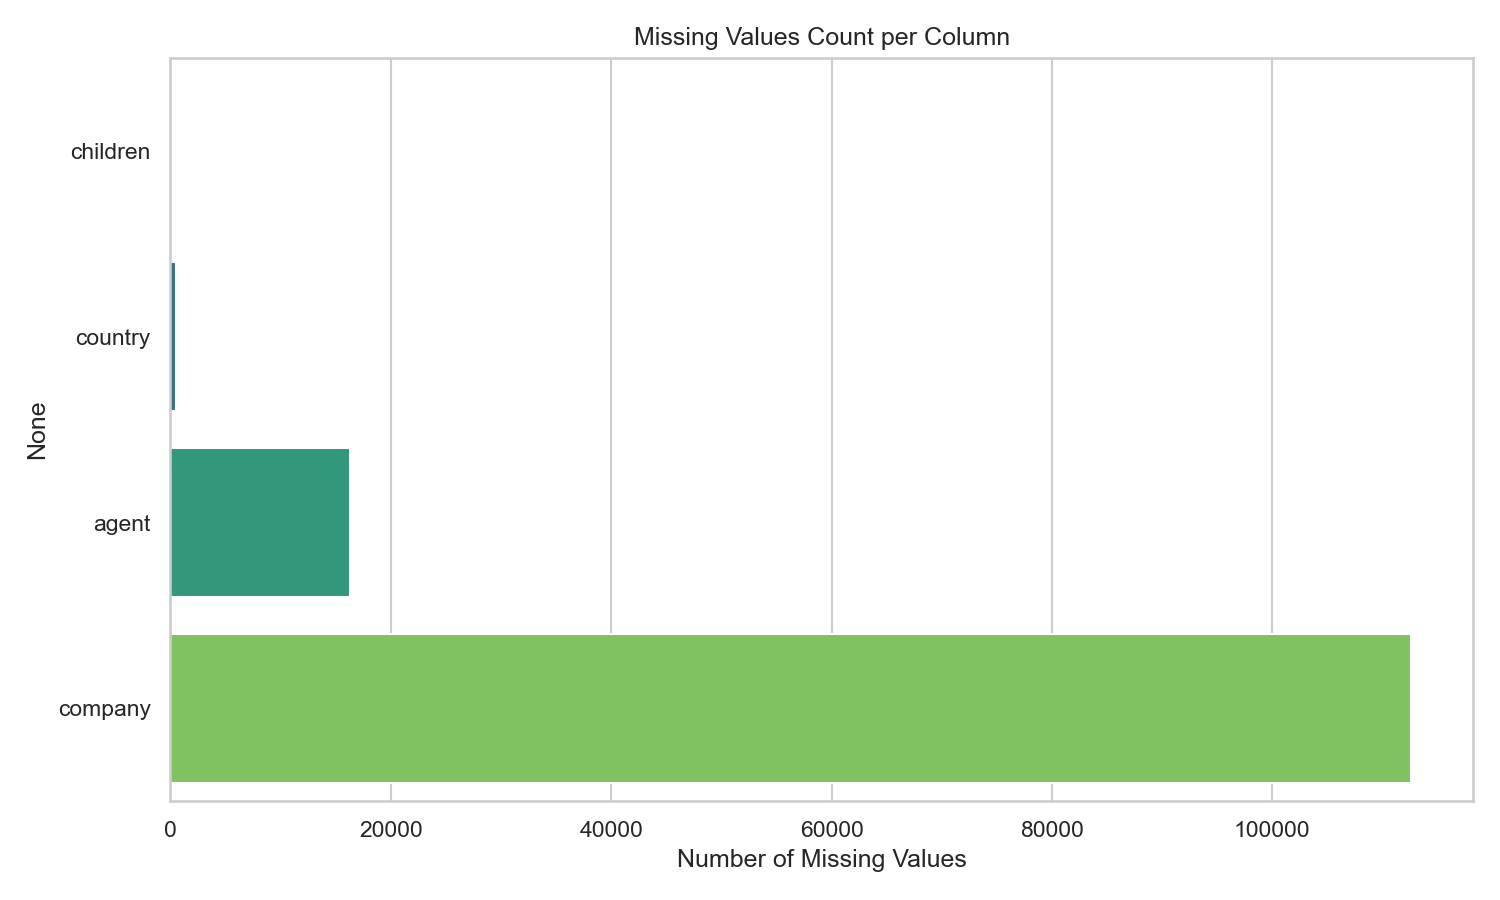

In [7]:
plot_missing_values(df_raw, FIGURES_DIR / "missing_values.png")
# Display generated image
from IPython.display import Image
Image(filename=FIGURES_DIR / "missing_values.png")

#### 6.2 Booking Cancellation Distribution

C:\Users\DELL\Downloads\Dynamic-Pricing-RL\src\visualization\eda.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


2026-07-17 10:42:56 | INFO     | eda | Saved Booking Distribution plot to: C:\Users\DELL\Downloads\Dynamic-Pricing-RL\outputs\figures\booking_distribution.png


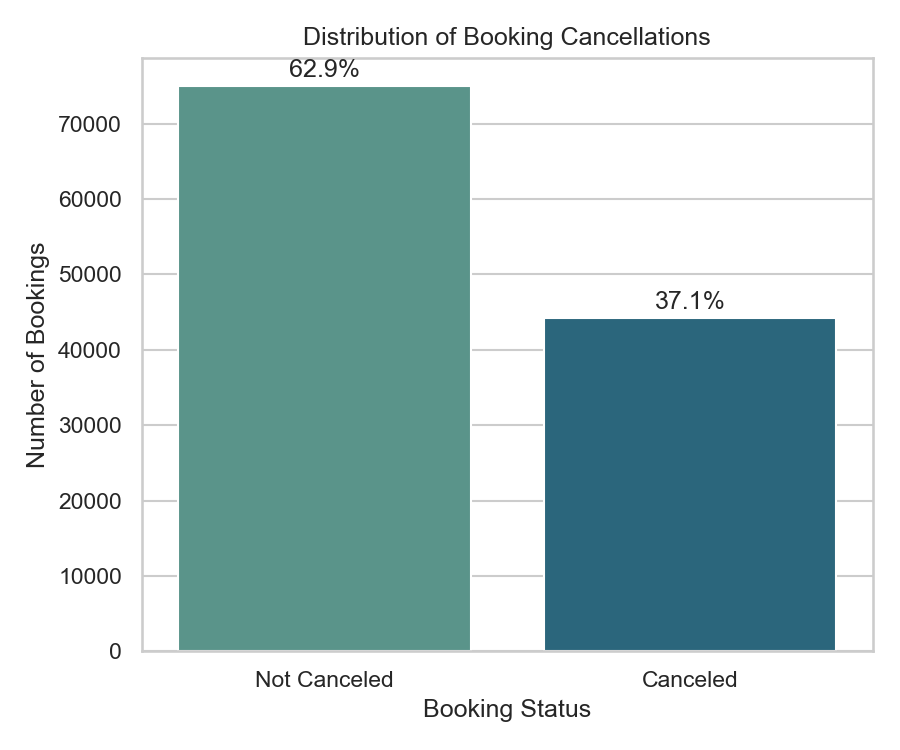

In [8]:
plot_booking_distribution(df_features, FIGURES_DIR / "booking_distribution.png")
Image(filename=FIGURES_DIR / "booking_distribution.png")

#### 6.3 Hotel Type Booking Count

C:\Users\DELL\Downloads\Dynamic-Pricing-RL\src\visualization\eda.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="hotel", palette="flare")


2026-07-17 10:42:57 | INFO     | eda | Saved Hotel Type Distribution plot to: C:\Users\DELL\Downloads\Dynamic-Pricing-RL\outputs\figures\hotel_type_distribution.png


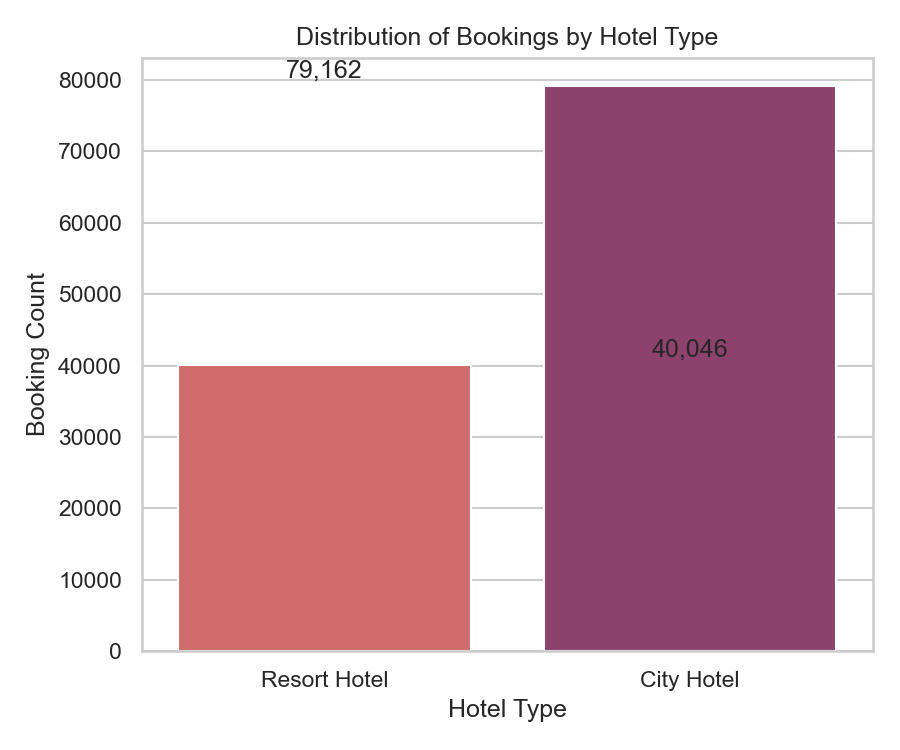

In [9]:
plot_hotel_type_distribution(df_features, FIGURES_DIR / "hotel_type_distribution.png")
Image(filename=FIGURES_DIR / "hotel_type_distribution.png")

#### 6.4 ADR distribution

2026-07-17 10:42:59 | INFO     | eda | Saved ADR Distribution plot to: C:\Users\DELL\Downloads\Dynamic-Pricing-RL\outputs\figures\adr_distribution.png


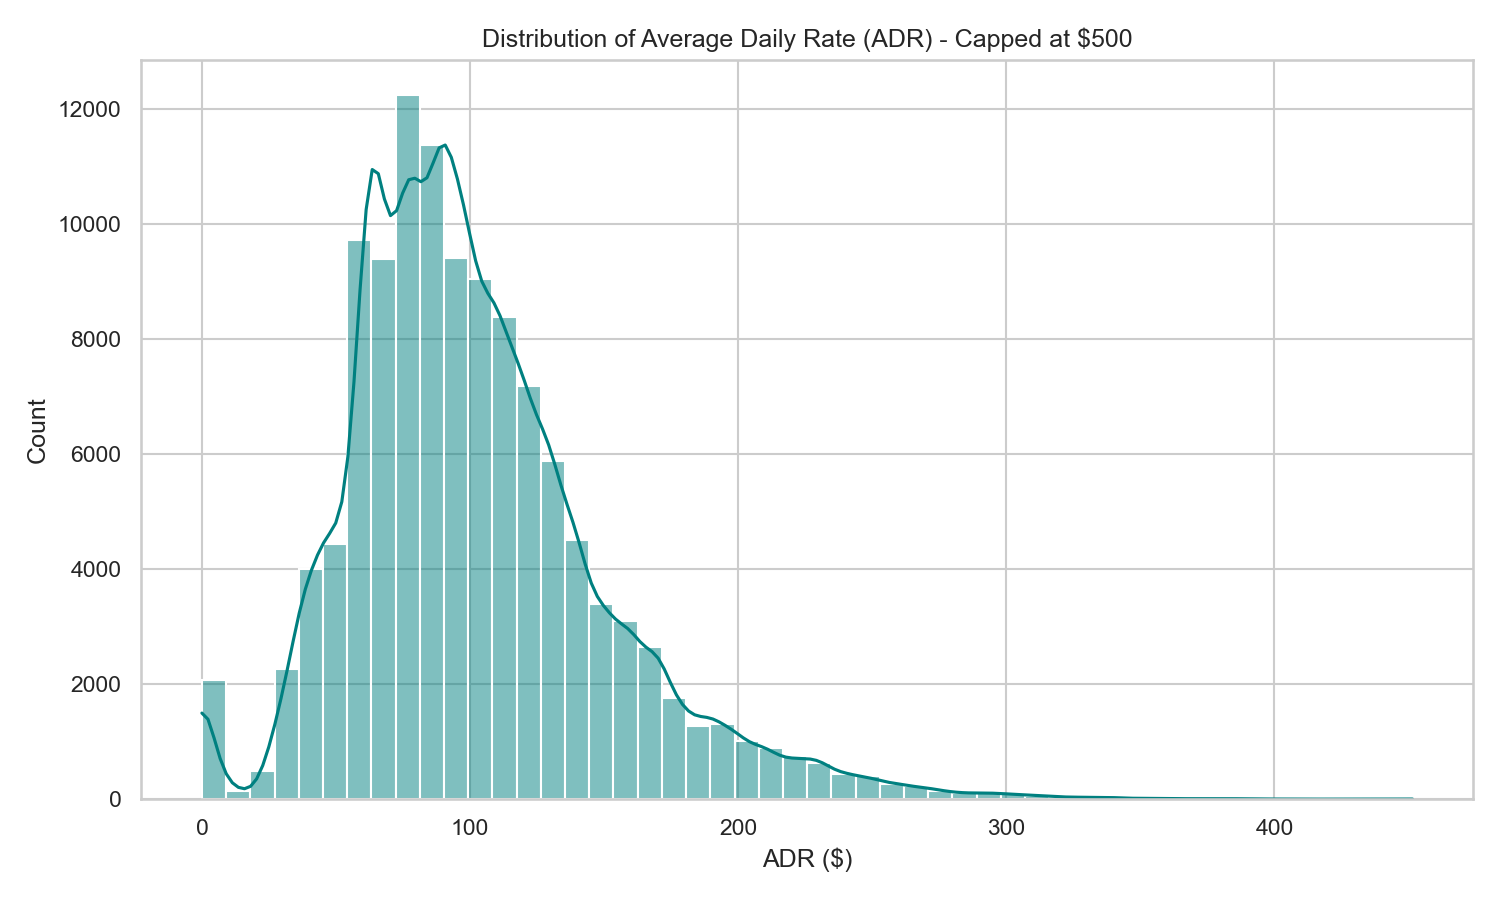

In [10]:
plot_adr_distribution(df_features, FIGURES_DIR / "adr_distribution.png")
Image(filename=FIGURES_DIR / "adr_distribution.png")

#### 6.5 ADR by Hotel Type and Cancellation

2026-07-17 10:43:00 | INFO     | eda | Saved ADR by Hotel plot to: C:\Users\DELL\Downloads\Dynamic-Pricing-RL\outputs\figures\adr_by_hotel.png


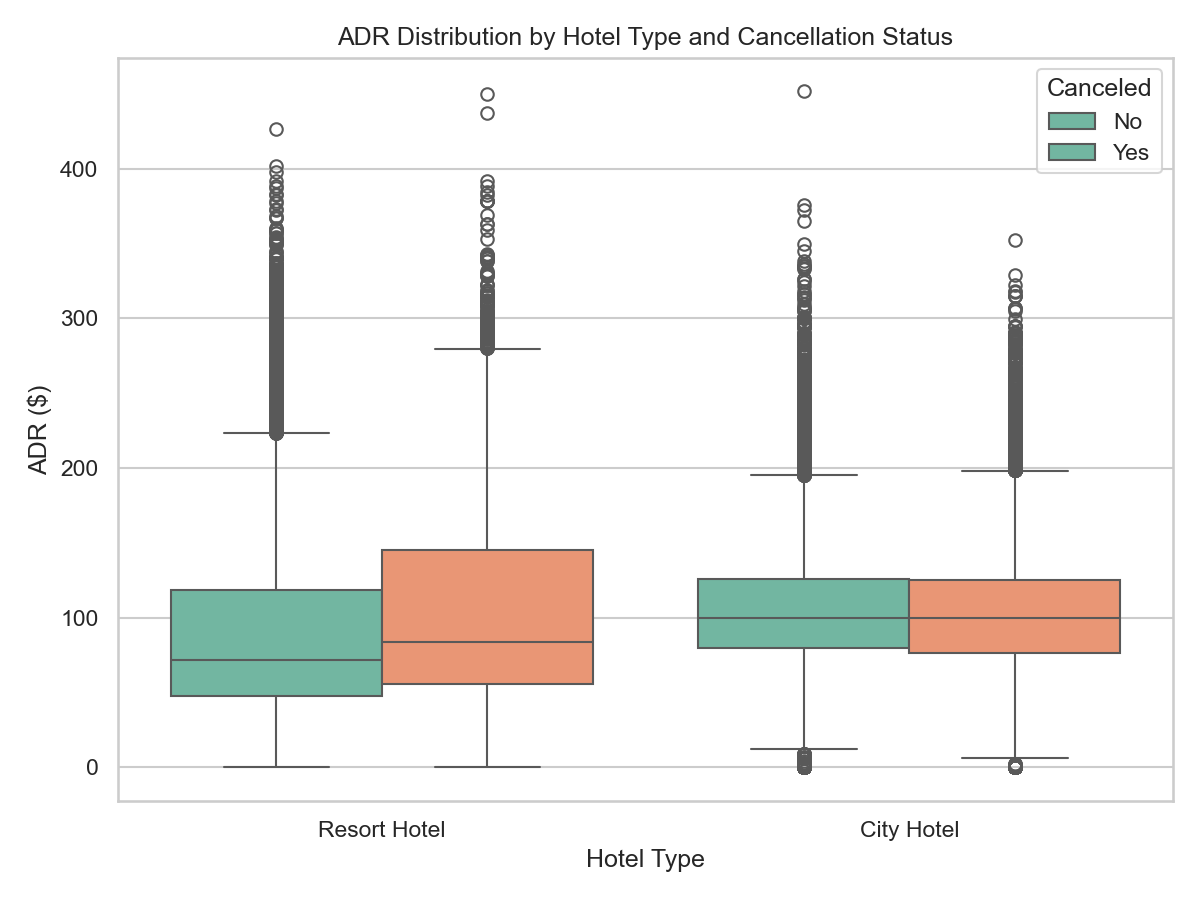

In [11]:
plot_adr_by_hotel(df_features, FIGURES_DIR / "adr_by_hotel.png")
Image(filename=FIGURES_DIR / "adr_by_hotel.png")

#### 6.6 Cancellation Rate by Market Segment

C:\Users\DELL\Downloads\Dynamic-Pricing-RL\src\visualization\eda.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


2026-07-17 10:43:00 | INFO     | eda | Saved Cancellation Analysis plot to: C:\Users\DELL\Downloads\Dynamic-Pricing-RL\outputs\figures\cancellation_analysis.png


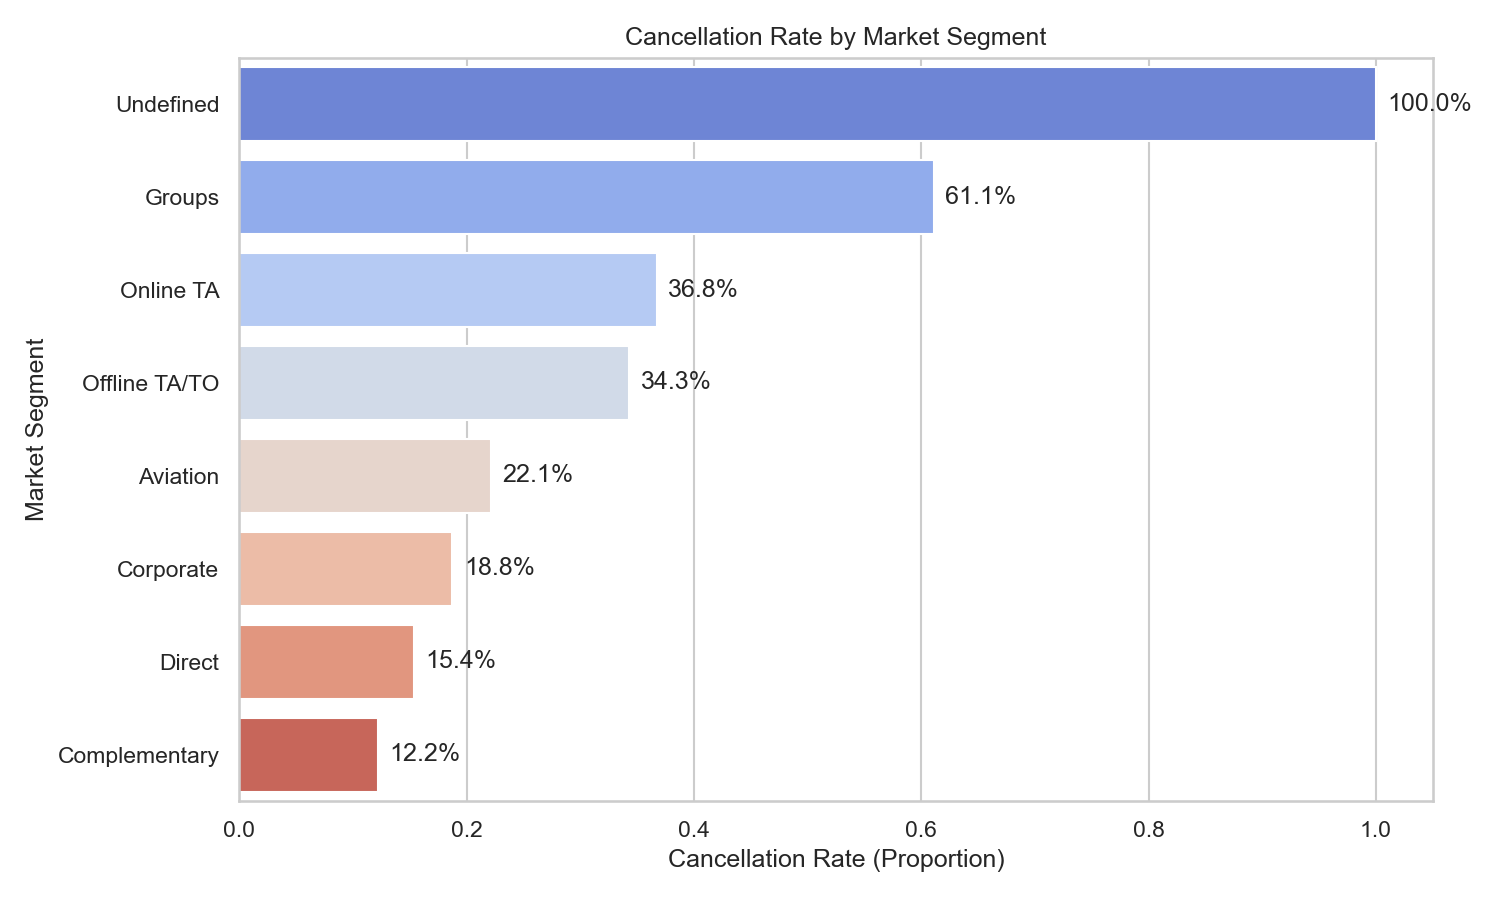

In [12]:
plot_cancellation_analysis(df_features, FIGURES_DIR / "cancellation_analysis.png")
Image(filename=FIGURES_DIR / "cancellation_analysis.png")

#### 6.7 Booking volume per Month

2026-07-17 10:43:01 | INFO     | eda | Saved Monthly Bookings plot to: C:\Users\DELL\Downloads\Dynamic-Pricing-RL\outputs\figures\monthly_bookings.png


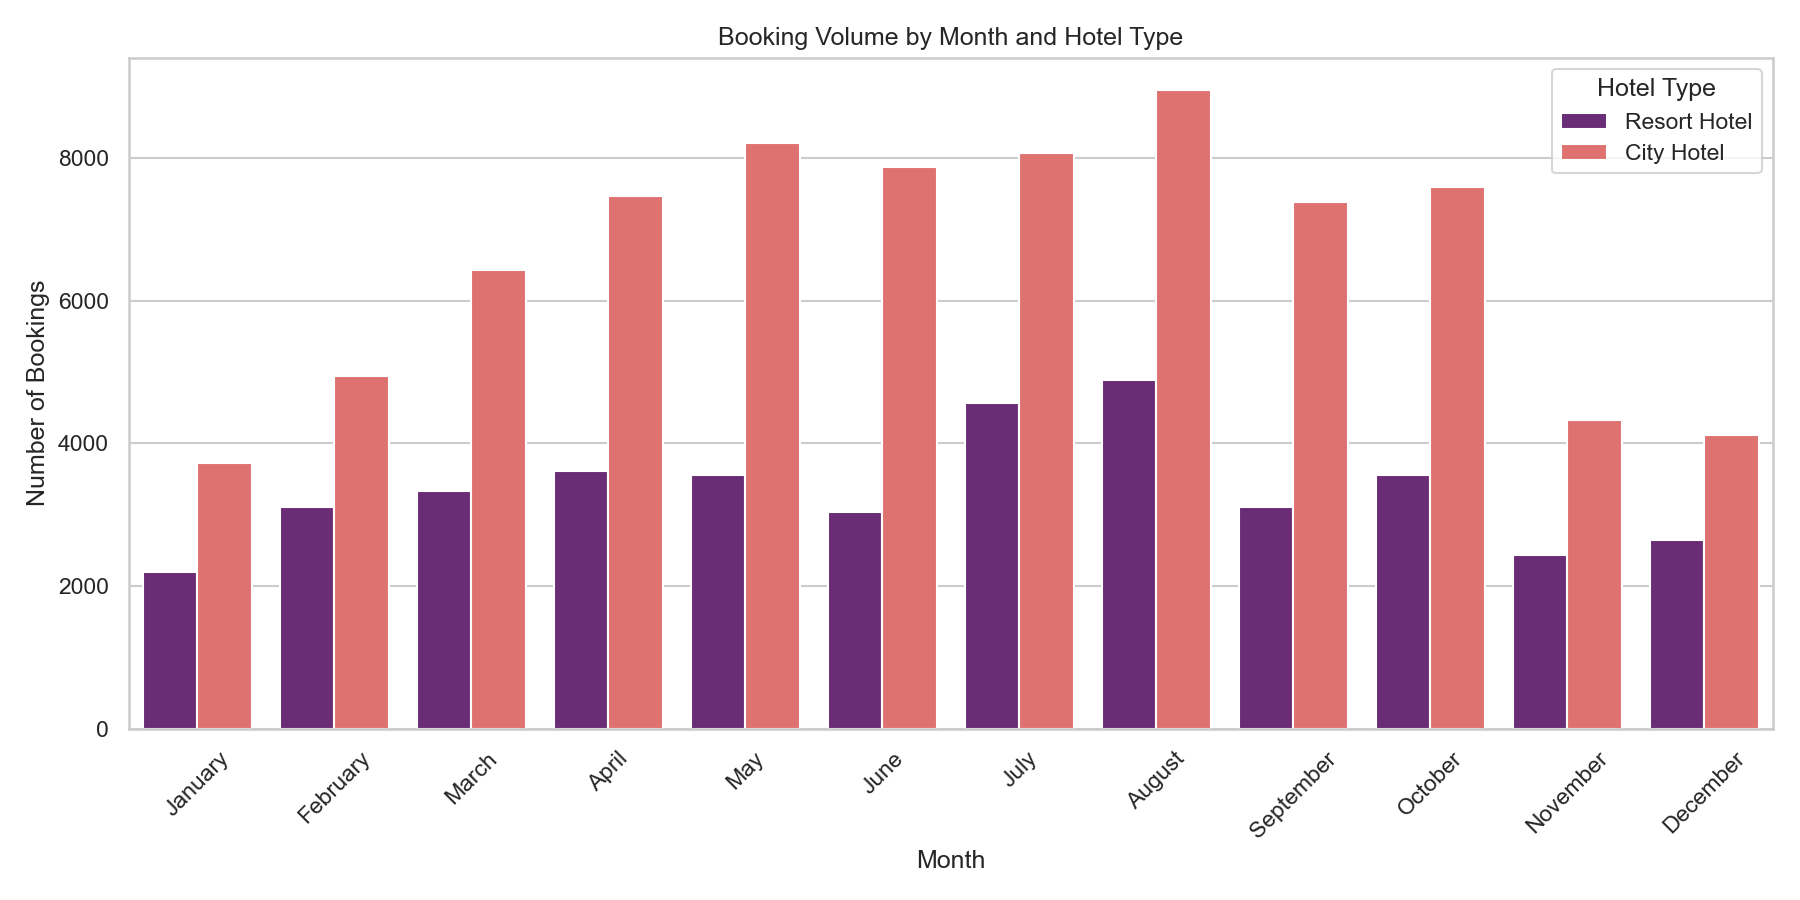

In [13]:
plot_monthly_bookings(df_features, FIGURES_DIR / "monthly_bookings.png")
Image(filename=FIGURES_DIR / "monthly_bookings.png")

#### 6.8 Lead Time Distribution

2026-07-17 10:43:02 | INFO     | eda | Saved Lead Time Distribution plot to: C:\Users\DELL\Downloads\Dynamic-Pricing-RL\outputs\figures\lead_time_distribution.png


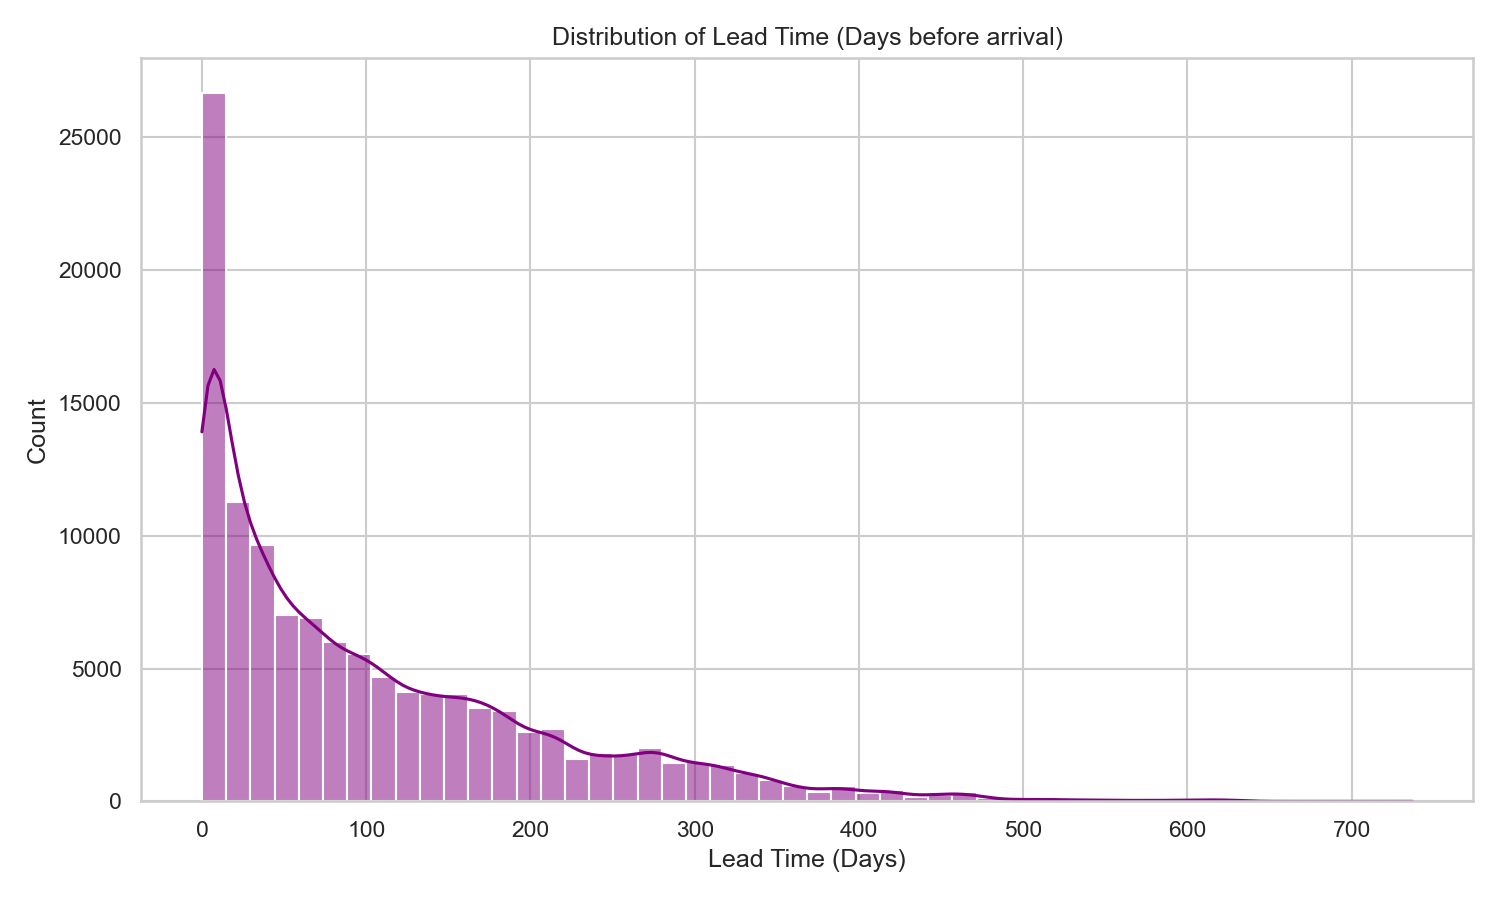

In [14]:
plot_lead_time_distribution(df_features, FIGURES_DIR / "lead_time_distribution.png")
Image(filename=FIGURES_DIR / "lead_time_distribution.png")

#### 6.9 Lead Time vs Cancellation Density

2026-07-17 10:43:04 | INFO     | eda | Saved Lead Time vs Cancellation plot to: C:\Users\DELL\Downloads\Dynamic-Pricing-RL\outputs\figures\lead_time_vs_cancellation.png


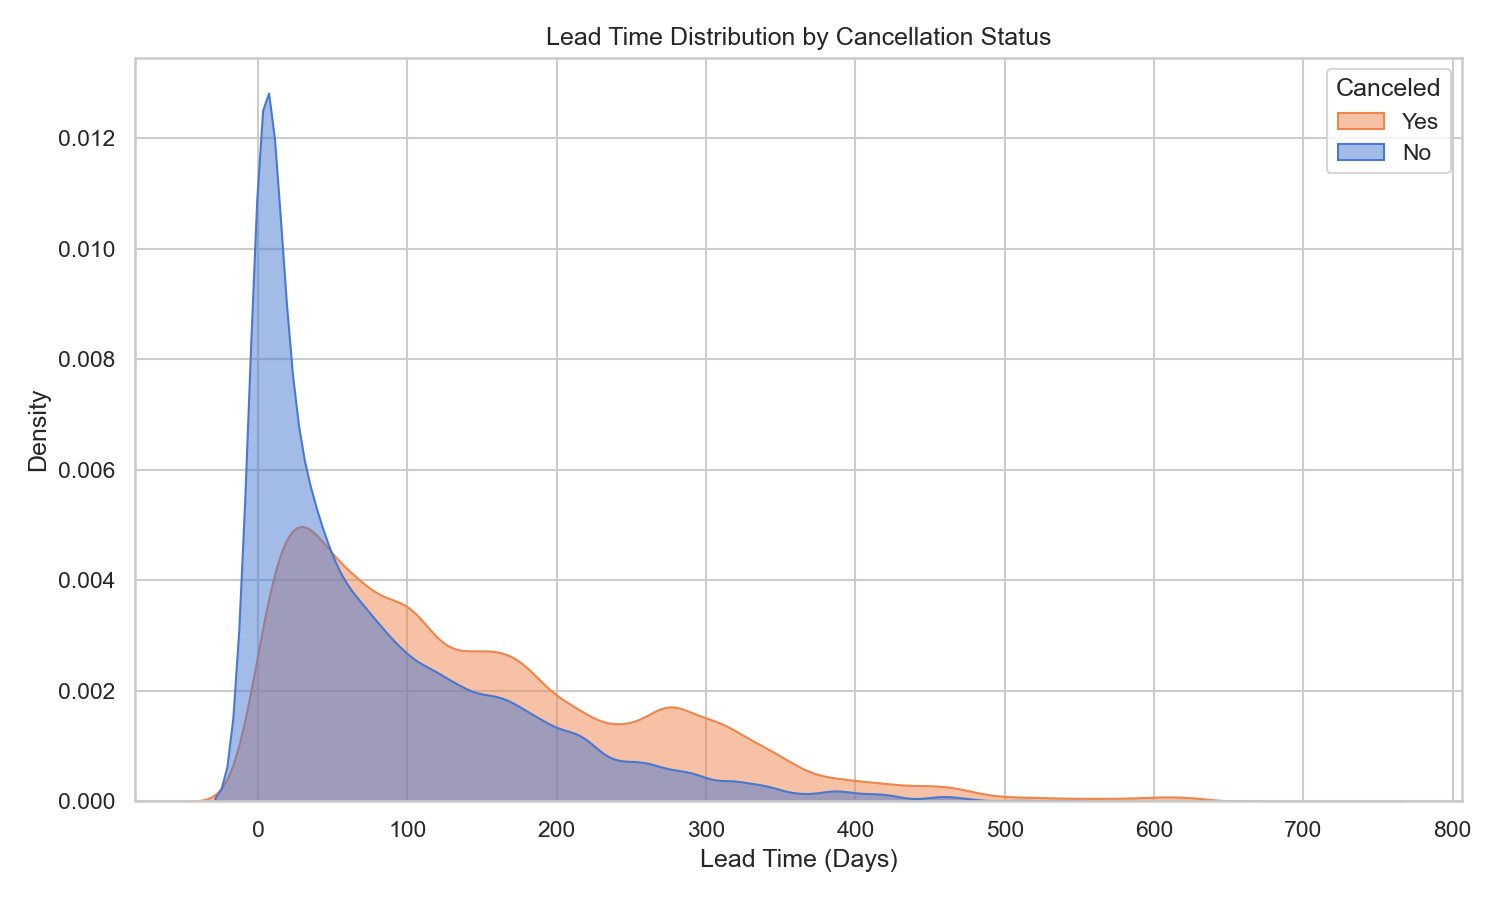

In [15]:
plot_lead_time_vs_cancellation(df_features, FIGURES_DIR / "lead_time_vs_cancellation.png")
Image(filename=FIGURES_DIR / "lead_time_vs_cancellation.png")

#### 6.10 Booking Count by Market Segment

C:\Users\DELL\Downloads\Dynamic-Pricing-RL\src\visualization\eda.py:260: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


2026-07-17 10:43:04 | INFO     | eda | Saved Market Segment plot to: C:\Users\DELL\Downloads\Dynamic-Pricing-RL\outputs\figures\market_segment.png


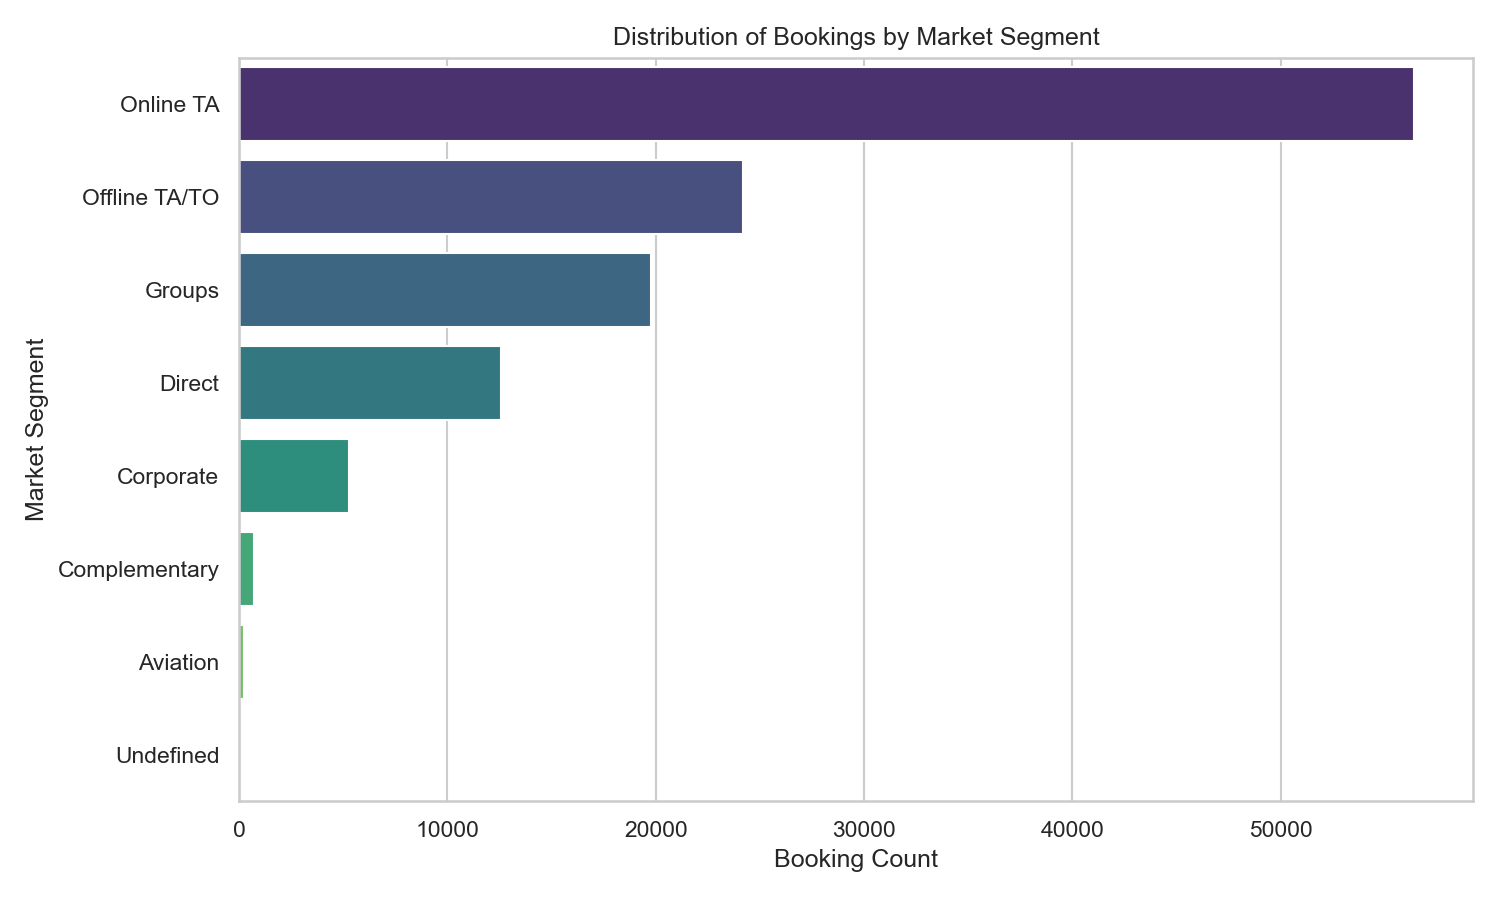

In [16]:
plot_market_segment(df_features, FIGURES_DIR / "market_segment.png")
Image(filename=FIGURES_DIR / "market_segment.png")

#### 6.11 Booking Count by Customer Type

C:\Users\DELL\Downloads\Dynamic-Pricing-RL\src\visualization\eda.py:279: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="customer_type", palette="rocket")


2026-07-17 10:43:04 | INFO     | eda | Saved Customer Type plot to: C:\Users\DELL\Downloads\Dynamic-Pricing-RL\outputs\figures\customer_type.png


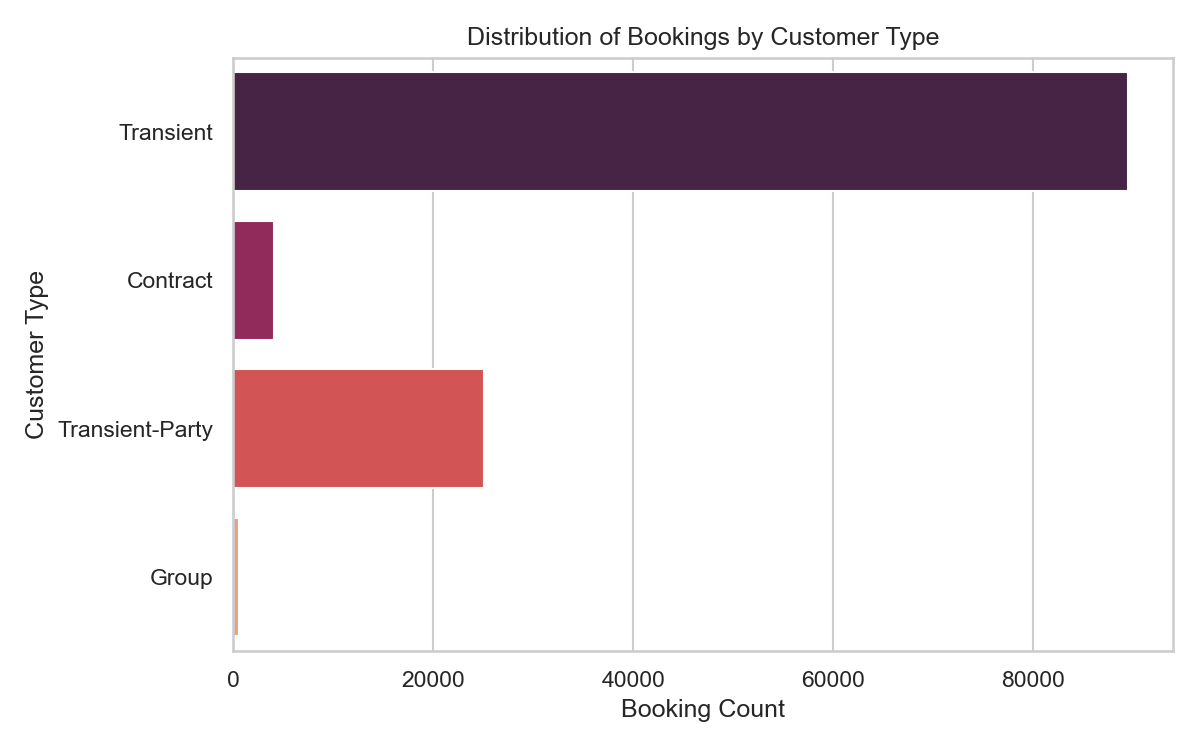

In [17]:
plot_customer_type(df_features, FIGURES_DIR / "customer_type.png")
Image(filename=FIGURES_DIR / "customer_type.png")

#### 6.12 Feature Correlation Heatmap

2026-07-17 10:43:06 | INFO     | eda | Saved Correlation Matrix plot to: C:\Users\DELL\Downloads\Dynamic-Pricing-RL\outputs\figures\correlation_matrix.png


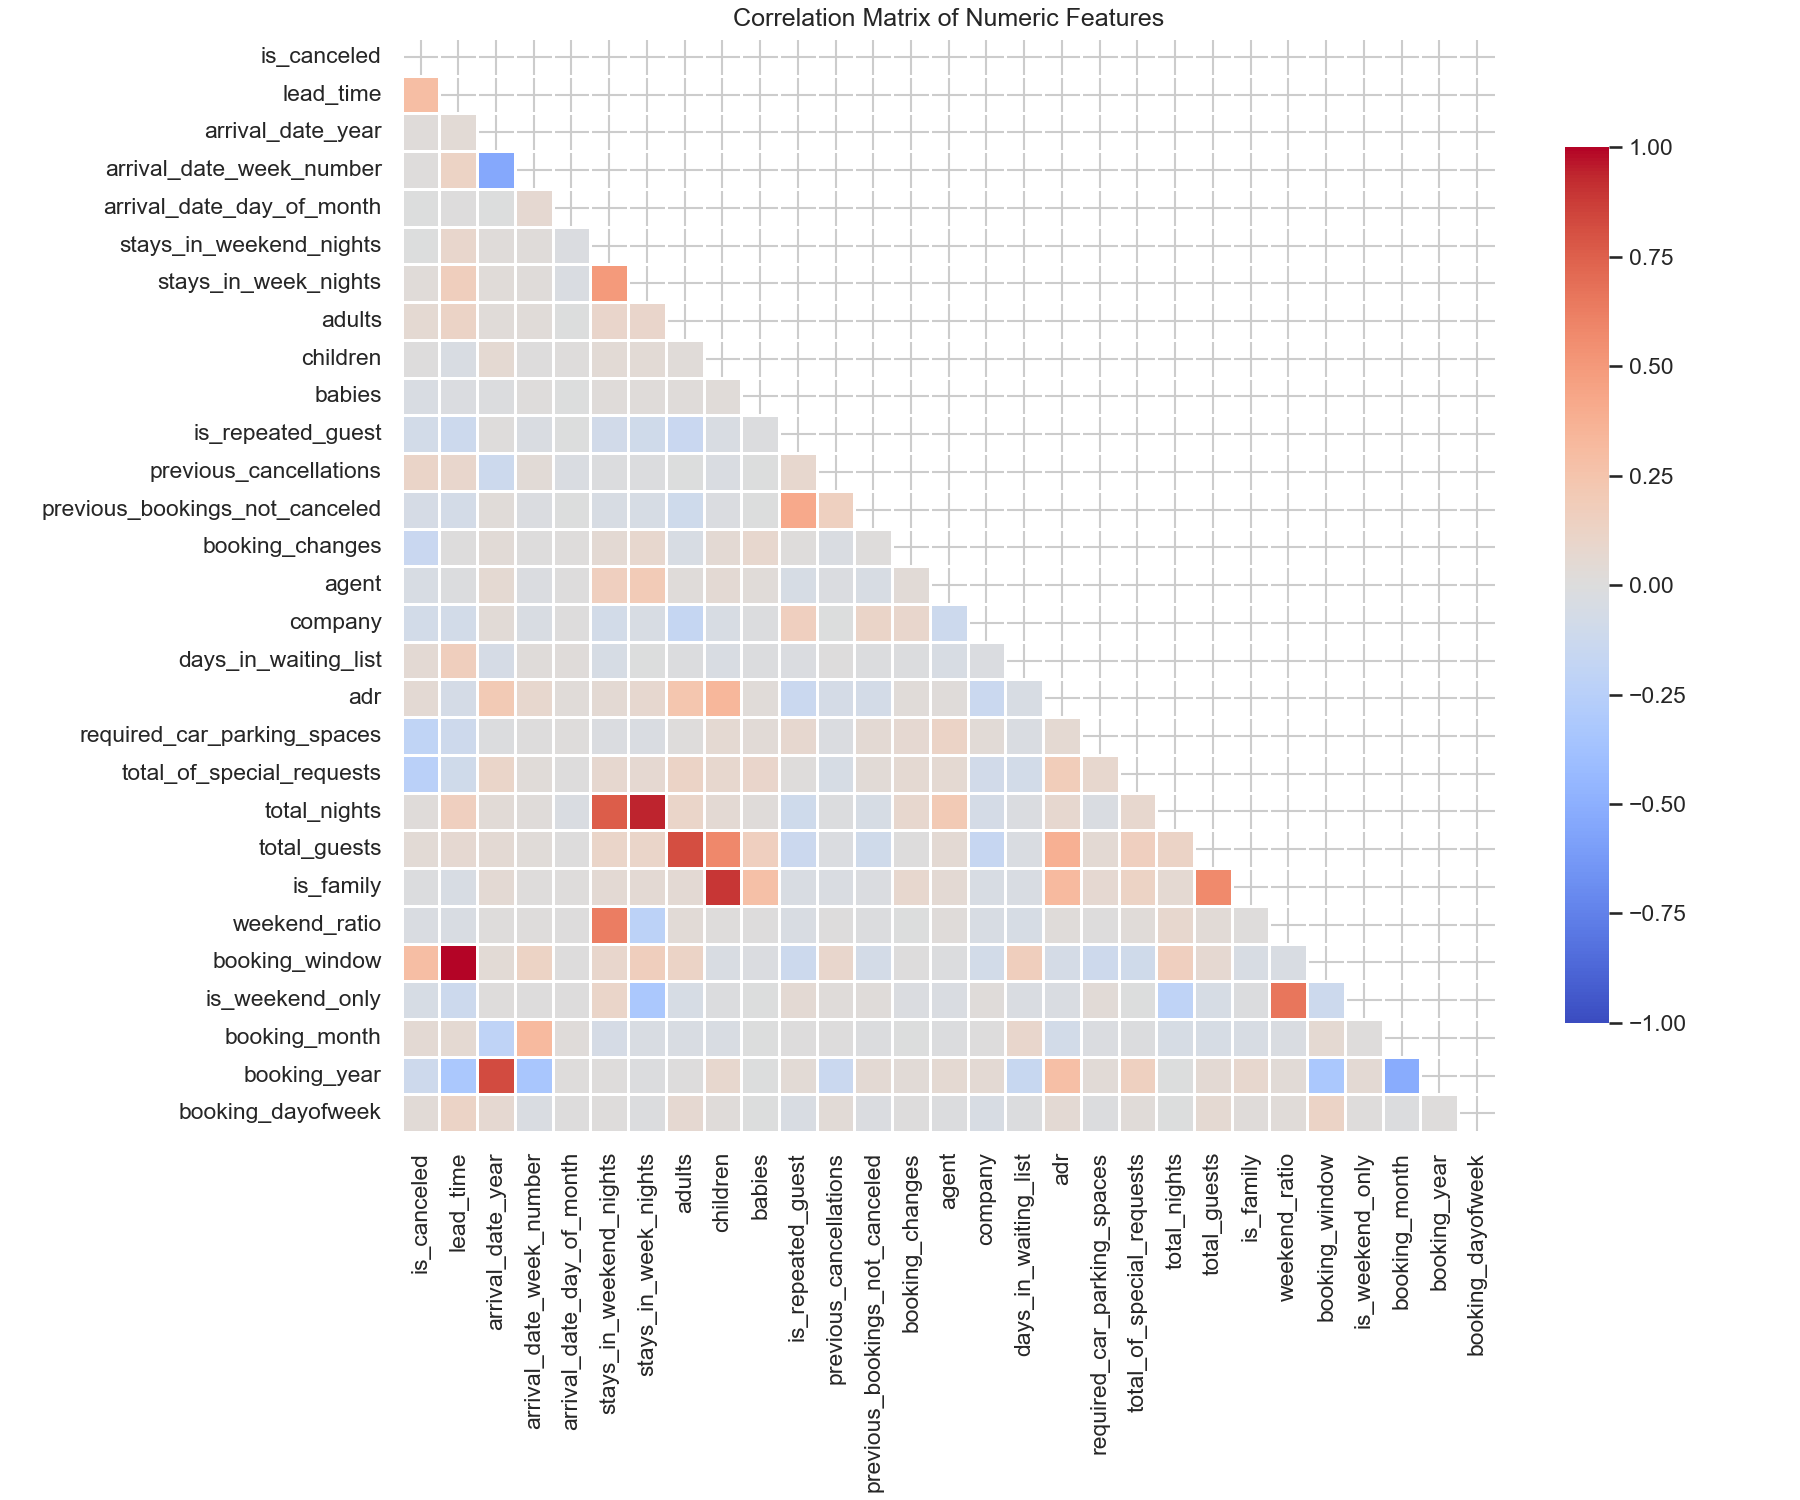

In [18]:
plot_correlation_matrix(df_features, FIGURES_DIR / "correlation_matrix.png")
Image(filename=FIGURES_DIR / "correlation_matrix.png")

### 7. Core Statistics Summary

In [19]:
# Print statistics of engineered features
df_features[["total_nights", "total_guests", "weekend_ratio", "booking_window"]].describe()

,total_nights,total_guests,weekend_ratio,booking_window
count,119208.000000,119208.000000,119208.000000,119208.000000
mean,3.426213,1.971210,0.253334,104.109045
std,2.540633,0.718882,0.280609,106.875835
min,0.000000,1.000000,0.000000,0.000000
25%,2.000000,2.000000,0.000000,18.000000
50%,3.000000,2.000000,0.250000,69.000000
75%,4.000000,2.000000,0.400000,161.000000
max,69.000000,55.000000,1.000000,737.000000
